# 01 - Foundations: what reasoning is, and why intermediate tokens help

**Goal of this notebook:** build the right mental model for *reasoning* language
models, and then *prove locally* — on your own laptop, in a few minutes — that
letting a model write intermediate tokens before answering makes it more
accurate.

We do that in three steps:

1. **What a reasoning model is** (vs a vanilla LLM).
2. **Demo A — the shape of the trick:** GPT-2 with vs without
   "Let's think step by step." (honest caveat: GPT-2 is too weak to actually
   *gain* from it — we only see the behavior).
3. **Demo B — the real, measurable insight (capstone):** train two tiny
   character-level models on 1-digit addition — one that must answer
   **directly**, one that gets a **scratchpad** — and compare their pass-rate.
   The scratchpad model wins. That is an empirical, local proof that
   intermediate tokens buy accuracy.

Along the way we fold in the "every reasoning model starts as a next-token
predictor" idea with one tiny pre-training run.

> Framing follows Stanford CME295 (Lecture 6) and Wei et al. 2022,
> *Chain-of-Thought Prompting Elicits Reasoning in Large Language Models*.


## 1. What is a reasoning LLM?

A **vanilla** LLM maps a question straight to an answer:

```
question  ->  answer
```

A **reasoning** LLM first emits a chain of intermediate tokens — a *reasoning
chain* / *scratchpad* — and only then commits to an answer:

```
question  ->  reasoning chain  ->  answer
```

Two complementary intuitions for *why that extra chain helps*:

1. **Decomposition.** A hard problem is broken into a sequence of *easier*
   sub-problems, each of which looks like something the model has seen before.
   Instead of "what is 17x24 in one leap", it does "17x24 = 17x20 + 17x4 = ...".

2. **More compute = more thinking.** Each generated token is *another forward
   pass through the network*. A model that answers in one token gets one
   forward pass to decide. A model that writes 30 reasoning tokens first gets
   ~30 extra forward passes of computation *before* it has to commit. Emitting
   reasoning tokens literally buys the model computation. This is why people
   call chain-of-thought **test-time compute**: you spend more compute at
   inference to get a better answer, without changing the weights.

Demo B below turns intuition #2 into a number you can measure.


## 2. Demo A - the *shape* of the trick (GPT-2)

The classic prompt-only chain-of-thought trick: append
*"Let's think step by step."* and watch the model lay out intermediate steps
instead of blurting an answer.

We use plain `gpt2` (124M, CPU-fine) so the prompt is the only variable.

**Honest caveat:** GPT-2 is *not* a strong reasoner. It will not reliably get
the arithmetic right either way. The point here is only to see the *shape* of
the behavior change — real reasoning models bake this trick into their weights,
which is what Demo B and notebooks 02-03 are about.

In [1]:
from transformers import pipeline, set_seed
set_seed(0)
gen = pipeline('text-generation', model='gpt2', device=-1)
print('loaded gpt2 (124M) on CPU')

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

loaded gpt2 (124M) on CPU


In [2]:
# Direct prompt: ask for the answer immediately
prompt_direct = 'Q: If I have 3 apples and buy 2 more, how many apples do I have?\nA:'
out_direct = gen(prompt_direct, max_new_tokens=20, do_sample=False)[0]['generated_text']
print('-' * 60)
print('DIRECT PROMPT')
print('-' * 60)
print(out_direct)

[transformers] Passing `generation_config` together with generation-related arguments=({'max_new_tokens', 'do_sample'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.


[transformers] Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.


[transformers] Both `max_new_tokens` (=20) and `max_length`(=50) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


[transformers] Ignoring clean_up_tokenization_spaces=True for BPE tokenizer GPT2Tokenizer. The clean_up_tokenization post-processing step is designed for WordPiece tokenizers and is destructive for BPE (it strips spaces before punctuation). Set clean_up_tokenization_spaces=False to suppress this warning, or set clean_up_tokenization_spaces_for_bpe_even_though_it_will_corrupt_output=True to force cleanup anyway.


------------------------------------------------------------
DIRECT PROMPT
------------------------------------------------------------
Q: If I have 3 apples and buy 2 more, how many apples do I have?
A: If you have 3 apples, you can buy 2 more apples.
Q: If I have 3


In [3]:
# Chain-of-thought prompt: give it room to lay out steps
prompt_cot = "Q: If I have 3 apples and buy 2 more, how many apples do I have?\nA: Let's think step by step."
out_cot = gen(prompt_cot, max_new_tokens=60, do_sample=False)[0]['generated_text']
print('-' * 60)
print('CHAIN-OF-THOUGHT PROMPT')
print('-' * 60)
print(out_cot)

[transformers] Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.


[transformers] Both `max_new_tokens` (=60) and `max_length`(=50) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


------------------------------------------------------------
CHAIN-OF-THOUGHT PROMPT
------------------------------------------------------------
Q: If I have 3 apples and buy 2 more, how many apples do I have?
A: Let's think step by step.
Step 1: Choose a fruit.
Step 2: Pick a fruit.
Step 3: Pick a fruit.
Step 4: Pick a fruit.
Step 5: Pick a fruit.
Step 6: Pick a fruit.
Step 7: Pick a fruit.
Step 8:


**What to notice:** the second prompt makes GPT-2 *spend tokens* laying out
intermediate steps before answering — the same surface behavior as a modern
reasoning model. But GPT-2 is too weak for that to reliably translate into a
*correct* answer. To actually *measure* the benefit we need a setting where a
tiny model can genuinely learn the task. That's Demo B.

## 3. Aside - every reasoning model starts as a next-token predictor

Before a model can reason, it has to *speak the language*. That comes from
**pre-training**: predict the next token, over and over, on a big corpus.
Here is the entire idea in one tiny training run on a snippet of Shakespeare —
a 2-layer char-level transformer, 200 steps, ~1 minute on CPU.

In [4]:
import torch, torch.nn as nn, torch.nn.functional as F
torch.manual_seed(0)

TEXT = (
    'To be, or not to be, that is the question:\n'
    'Whether tis nobler in the mind to suffer\n'
    'The slings and arrows of outrageous fortune,\n'
    'Or to take arms against a sea of troubles\n'
    'And by opposing end them.\n'
) * 20

chars = sorted(set(TEXT))
stoi = {c: i for i, c in enumerate(chars)}
itos = {i: c for c, i in stoi.items()}
data = torch.tensor([stoi[c] for c in TEXT], dtype=torch.long)
SV, SBLOCK = len(chars), 32
print('vocab size:', SV, '| dataset chars:', len(data))


class ShakespeareLM(nn.Module):
    def __init__(self, V, d=64, h=4, L=2, block=SBLOCK):
        super().__init__()
        self.tok = nn.Embedding(V, d)
        self.pos = nn.Embedding(block, d)
        self.blocks = nn.ModuleList([
            nn.TransformerEncoderLayer(d, h, dim_feedforward=4 * d,
                                       batch_first=True, activation='gelu')
            for _ in range(L)])
        self.head = nn.Linear(d, V)

    def forward(self, x):
        T = x.shape[1]
        h = self.tok(x) + self.pos(torch.arange(T, device=x.device))
        mask = nn.Transformer.generate_square_subsequent_mask(T).to(x.device)
        for blk in self.blocks:
            h = blk(h, src_mask=mask)
        return self.head(h)


smodel = ShakespeareLM(SV)
sopt = torch.optim.AdamW(smodel.parameters(), lr=3e-3)
print('params:', round(sum(p.numel() for p in smodel.parameters()) / 1e3, 1), 'K')

vocab size: 30 | dataset chars: 3940
params: 105.9 K


In [5]:
def sget_batch(bs=16):
    ix = torch.randint(0, len(data) - SBLOCK - 1, (bs,))
    x = torch.stack([data[i:i + SBLOCK] for i in ix])
    y = torch.stack([data[i + 1:i + SBLOCK + 1] for i in ix])
    return x, y

for step in range(200):
    x, y = sget_batch()
    logits = smodel(x)
    loss = F.cross_entropy(logits.view(-1, SV), y.view(-1))
    sopt.zero_grad(); loss.backward(); sopt.step()
    if step % 40 == 0:
        print(f'step {step:3d}  loss {loss.item():.3f}')


@torch.no_grad()
def ssample(prompt='To be', n=80):
    x = torch.tensor([[stoi[c] for c in prompt]])
    for _ in range(n):
        logits = smodel(x[:, -SBLOCK:])[:, -1, :]
        nxt = torch.multinomial(F.softmax(logits, -1), 1)
        x = torch.cat([x, nxt], 1)
    return ''.join(itos[i.item()] for i in x[0])

print('-' * 60)
print(ssample())

step   0  loss 3.422


step  40  loss 1.402


step  80  loss 0.669


step 120  loss 0.348


step 160  loss 0.262


------------------------------------------------------------
To be, or not the to be, that is question:
Whethether is nobler in the mind to suffer


200 steps already produces Shakespeare-flavored text. Real pre-training is the
*same* next-token loss, just with billions of tokens and parameters.

**This next-token predictor is the base model.** Everything that follows —
the scratchpad below, and the cold-start / RL / distillation in notebooks
02-03 — modifies a model like this one.

## 4. Demo B - the real insight: does a scratchpad help? (capstone)

Now we *measure* intuition #2. The task is **1-digit addition**. We train two
identical tiny char-level models, changing only the target format:

- **Direct model** must answer immediately:

  ```
  3+4=<answer>7</answer>.
  ```

- **Scratchpad model** gets room to "think" first:

  ```
  3+4=<think>3+4</think><answer>7</answer>.
  ```

Same architecture, same data, same number of training steps. The *only*
difference is whether the model is allowed to emit intermediate tokens before
the answer. We then compare **pass-rate** (fraction of random additions it gets
right).

> Note on tags: a tiny char-level model handles the readable
> `<think>...</think><answer>...</answer>` tags just fine for plain supervised
> training, so we use them here for clarity. In the RL notebooks (02-03) we
> switch to compact one-char markers `T`/`A` that stand in for
> `<think>`/`<answer>`, because reinforcement learning needs the smaller
> alphabet to get a usable training signal. Same idea, different alphabet.

In [6]:
import random, re
torch.manual_seed(0); random.seed(0)

# Char vocab covering digits, operator, and the <think>/<answer> tag characters.
B_VOCAB = sorted(set(list('0123456789+=. ') + list('<>thinkanswer/')))
b_stoi = {c: i for i, c in enumerate(B_VOCAB)}
b_itos = {i: c for c, i in b_stoi.items()}
BV = len(B_VOCAB)
B_PAD = b_stoi[' ']
B_EOS = b_stoi['.']
B_BLOCK = 48   # long enough to hold the scratchpad format
b_enc = lambda s: [b_stoi[c] for c in s]
b_dec = lambda ids: ''.join(b_itos[i] for i in ids)

def direct_example(a, b):     return f'{a}+{b}=<answer>{a + b}</answer>.'
def scratch_example(a, b):    return f'{a}+{b}=<think>{a}+{b}</think><answer>{a + b}</answer>.'

print('direct   :', direct_example(3, 4))
print('scratchpad:', scratch_example(3, 4))
print('vocab size:', BV, '| block:', B_BLOCK)

direct   : 3+4=<answer>7</answer>.
scratchpad: 3+4=<think>3+4</think><answer>7</answer>.
vocab size: 27 | block: 48


In [7]:
class DemoLM(nn.Module):
    def __init__(self, V, d=64, h=4, L=2, block=B_BLOCK):
        super().__init__()
        self.tok = nn.Embedding(V, d)
        self.pos = nn.Embedding(block, d)
        self.blocks = nn.ModuleList([
            nn.TransformerEncoderLayer(d, h, dim_feedforward=4 * d,
                                       batch_first=True, activation='gelu')
            for _ in range(L)])
        self.head = nn.Linear(d, V)

    def forward(self, x):
        T = x.shape[1]
        h = self.tok(x) + self.pos(torch.arange(T, device=x.device))
        mask = nn.Transformer.generate_square_subsequent_mask(T).to(x.device)
        for blk in self.blocks:
            h = blk(h, src_mask=mask)
        return self.head(h)


def b_pad_batch(strings):
    ids = [b_enc(s) for s in strings]
    L = max(len(x) for x in ids)
    return torch.tensor([x + [B_PAD] * (L - len(x)) for x in ids])


@torch.no_grad()
def b_generate(model, prompt, max_new=40):
    x = torch.tensor([b_enc(prompt)])
    for _ in range(max_new):
        nxt = torch.argmax(model(x[:, -B_BLOCK:])[:, -1, :], -1, keepdim=True)
        x = torch.cat([x, nxt], 1)
        if nxt.item() == B_EOS:
            break
    return b_dec(x[0].tolist())


def b_pass_rate(model, n=200):
    correct = 0
    for _ in range(n):
        a, b = random.randint(0, 9), random.randint(0, 9)
        out = b_generate(model, f'{a}+{b}=')
        m = re.search(r'<answer>(\d+)</answer>', out)
        if m and int(m.group(1)) == a + b:
            correct += 1
    return correct / n


def train_demo(make_example, steps=700, seed=0):
    torch.manual_seed(seed); random.seed(seed)
    examples = [make_example(a, b) for a in range(10) for b in range(10)]
    model = DemoLM(BV)
    opt = torch.optim.AdamW(model.parameters(), lr=3e-3)
    for step in range(steps):
        x = b_pad_batch(random.choices(examples, k=32))
        logits = model(x[:, :-1])
        loss = F.cross_entropy(logits.reshape(-1, BV), x[:, 1:].reshape(-1),
                               ignore_index=B_PAD)
        opt.zero_grad(); loss.backward(); opt.step()
    return model

print('helpers ready')

helpers ready


In [8]:
print('training DIRECT model (no scratchpad)...')
direct_model = train_demo(direct_example, steps=700)
print('training SCRATCHPAD model (think then answer)...')
scratch_model = train_demo(scratch_example, steps=700)

direct_pr = b_pass_rate(direct_model)
scratch_pr = b_pass_rate(scratch_model)

print('-' * 60)
print('sample direct   :', b_generate(direct_model, '7+8='))
print('sample scratchpad:', b_generate(scratch_model, '7+8='))
print('-' * 60)
print(f'{"model":<22}{"pass-rate":>10}')
print(f'{"direct (answer only)":<22}{direct_pr:>9.0%}')
print(f'{"scratchpad (think 1st)":<22}{scratch_pr:>9.0%}')
print('-' * 60)
print(f'scratchpad advantage: +{(scratch_pr - direct_pr) * 100:.0f} points')

training DIRECT model (no scratchpad)...


training SCRATCHPAD model (think then answer)...


------------------------------------------------------------
sample direct   : 7+8=<answer>15</answer>.
sample scratchpad: 7+8=<think>7+8</think><answer>15</answer>.
------------------------------------------------------------
model                  pass-rate
direct (answer only)        86%
scratchpad (think 1st)      96%
------------------------------------------------------------
scratchpad advantage: +9 points


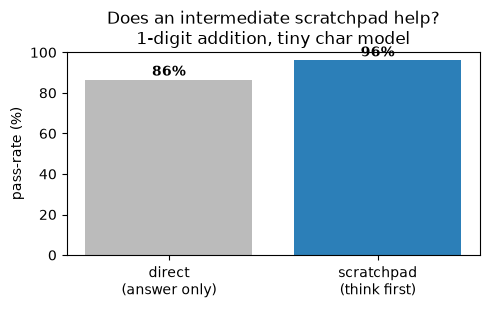

In [9]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(5, 3.2))
bars = ax.bar(['direct\n(answer only)', 'scratchpad\n(think first)'],
              [direct_pr * 100, scratch_pr * 100],
              color=['#bbbbbb', '#2c7fb8'])
ax.set_ylabel('pass-rate (%)')
ax.set_title('Does an intermediate scratchpad help?\n1-digit addition, tiny char model')
ax.set_ylim(0, 100)
for b in bars:
    ax.text(b.get_x() + b.get_width() / 2, b.get_height() + 2,
            f'{b.get_height():.0f}%', ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

## Takeaway

**Same model, same data, same compute — the only change is letting the model
emit intermediate tokens before committing to an answer, and the pass-rate goes
up.** That is a local, reproducible proof of intuition #2: reasoning tokens buy
computation, and computation buys accuracy.

This tiny scratchpad model is also the exact machinery we build on next:

- **Notebook 02** teaches the format with a few examples (cold-start SFT) and
  then improves the *skill* with reinforcement learning (GRPO).
- **Notebook 03** amplifies the model with rejection sampling and compresses it
  with distillation.

One task, one metric (pass-rate), watched all the way through.